In [208]:
import pandas as pd

data = pd.read_csv("/content/data.csv",encoding='latin1')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [209]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [210]:
#checking nulls
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [211]:
data.dropna(inplace=True)
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [212]:
#checking duplicates
data.duplicated().sum()


np.int64(5225)

In [213]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [214]:
#checking values
data.describe()

,Quantity,UnitPrice,CustomerID
count,401604.000000,401604.000000,401604.000000
mean,12.183273,3.474064,15281.160818
std,250.283037,69.764035,1714.006089
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13939.000000
50%,5.000000,1.950000,15145.000000
75%,12.000000,3.750000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [215]:
print("Number of negative Quantity values: " , (data['Quantity'] < 0).sum())

Number of negative Quantity values:  8872


In [216]:
data = data[data['Quantity'] > 0]
print("Number of negative Quantity values: " , (data['Quantity'] < 0).sum())

Number of negative Quantity values:  0


In [217]:
#getting RFM
data['Total_Amount'] = data['Quantity'] * data['UnitPrice']

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Total_Amount': 'sum'
})

rfm.rename(columns = {
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Total_Amount': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


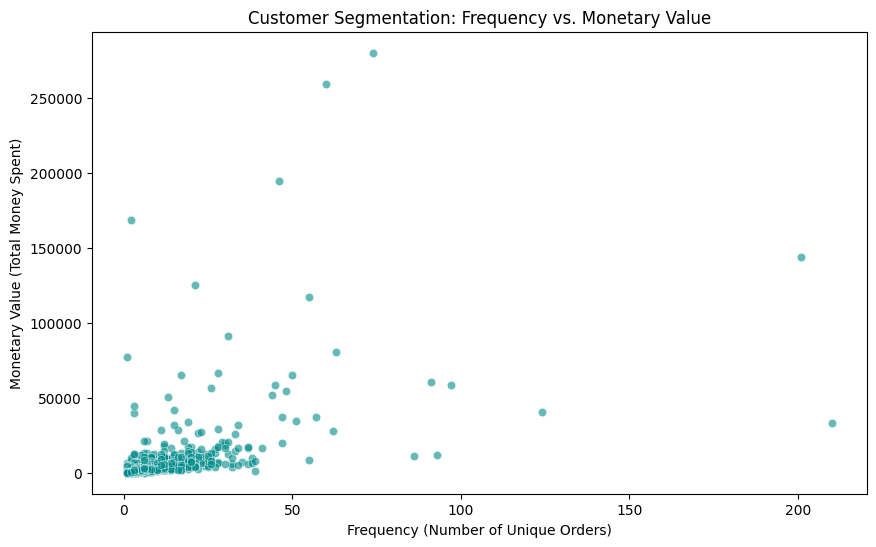

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(data=rfm, x='Frequency', y='Monetary',color='darkcyan',alpha=0.6)
plt.title('Customer Segmentation: Frequency vs. Monetary Value')
plt.xlabel('Frequency (Number of Unique Orders)')
plt.ylabel('Monetary Value (Total Money Spent)')
plt.show()

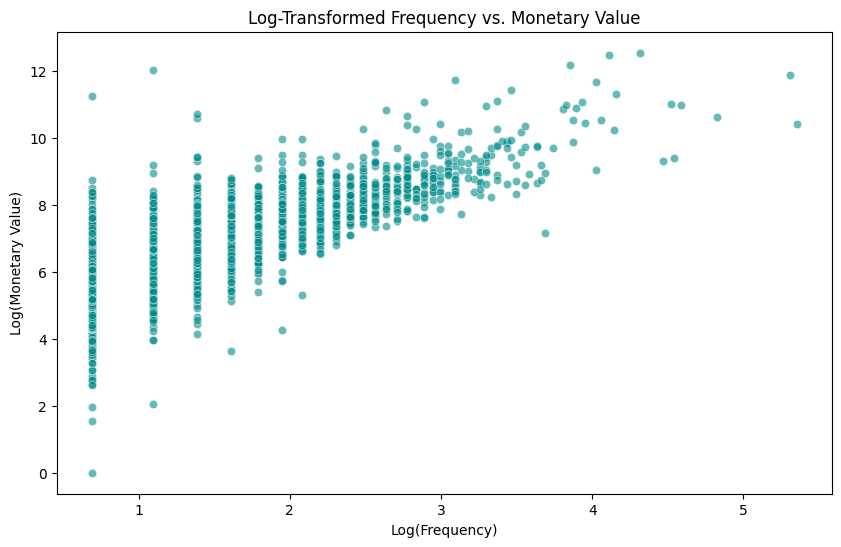

In [219]:
#Log tranforming rfm
import numpy as np
rfm_log = rfm.copy()
rfm_log['log_Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['log_Monetary'] = np.log1p(rfm_log['Monetary'])
plt.figure(figsize=(10,6))

sns.scatterplot(data=rfm_log, x='log_Frequency', y='log_Monetary',color='darkcyan',alpha=0.6)
plt.title('Log-Transformed Frequency vs. Monetary Value')
plt.xlabel('Log(Frequency)')
plt.ylabel('Log(Monetary Value)')
plt.show()

In [223]:
#Preparing data for modeling
from sklearn.preprocessing import StandardScaler

rfm_model = rfm.copy()
rfm_model['Frequency'] = np.log1p(rfm_model['Frequency'])
rfm_model['Recency'] = np.log1p(rfm_model['Recency'])
rfm_model['Monetary'] = np.log1p(rfm_model['Monetary'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(rfm_model)

X = pd.DataFrame(scaled_features, columns=['Recency','Frequency','Monetary'], index=rfm.index)
X.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.462236,-0.955013,3.697687
12347.0,-2.038611,1.074523,1.411820
12348.0,0.373310,0.386437,0.719046
12349.0,-0.622914,-0.955013,0.701362
12350.0,1.424800,-0.955013,-0.611449


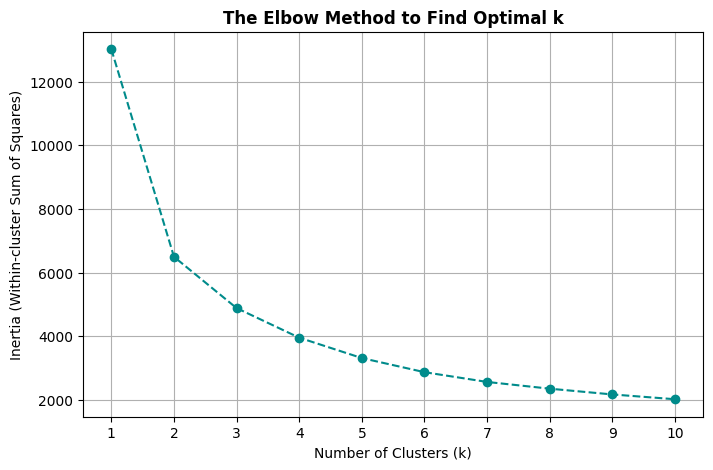

In [225]:
#Getting the best number of clusters (K)
from sklearn.cluster import KMeans

inertia = []
K_range = range(1,11)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='darkcyan')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('The Elbow Method to Find Optimal k', fontsize=12, fontweight='bold')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [227]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
kmeans.fit(X)

rfm['Cluster'] = kmeans.labels_

print("Cosutomer count per cluster:")
print(rfm['Cluster'].value_counts())

cluster_analysis = rfm.groupby('Cluster').mean()
print("\nAverage RFM values per Cluster:")
print(cluster_analysis)

Cosutomer count per cluster:
Cluster
0    1870
2    1703
1     766
Name: count, dtype: int64

Average RFM values per Cluster:
            Recency  Frequency     Monetary
Cluster                                    
0        167.205882   1.348663   359.375027
1         16.616188  13.365535  7909.065927
2         44.647093   3.391662  1266.490366


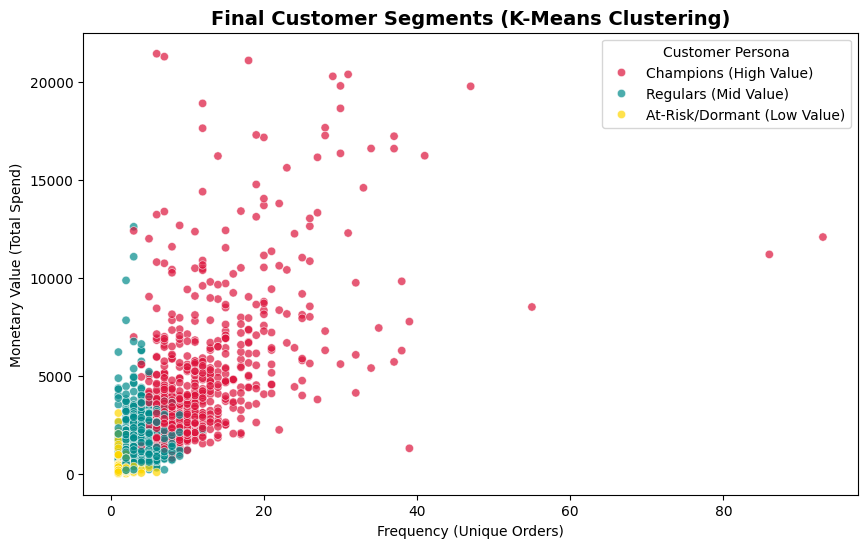

In [228]:
#Map customer segments to the cluster numbers
cluster_map = {
    1: 'Champions (High Value)',
    2: 'Regulars (Mid Value)',
    0: 'At-Risk/Dormant (Low Value)'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm[rfm['Monetary'] < 25000],
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette=['crimson', 'darkcyan', 'gold'],
    alpha=0.7
)

plt.title('Final Customer Segments (K-Means Clustering)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency (Unique Orders)')
plt.ylabel('Monetary Value (Total Spend)')
plt.legend(title='Customer Persona')
plt.show()